<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/%D0%90%D1%83%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Работа 8
# Аугментация данных для классификации изображений CIFAR-10

## Цель работы

Освоить применение аугментации данных при обучении сверточных нейронных сетей для задачи классификации изображений.

В ходе работы необходимо:

- загрузить и подготовить набор данных CIFAR-10;
- изучить примеры изображений из датасета;
- создать слой аугментации изображений;
- визуально оценить, как меняются изображения после аугментации;
- обучить CNN с использованием аугментации;
- построить графики обучения;
- проанализировать качество модели;
- сделать вывод о влиянии аугментации на обучение.

## Что такое аугментация данных?

**Аугментация данных** — это способ искусственно увеличить разнообразие обучающей выборки за счёт случайных преобразований изображений.

Например, изображение можно:

- немного повернуть;
- сдвинуть;
- приблизить или отдалить;
- отразить по горизонтали;
- изменить контрастность.

При этом объект на изображении должен остаться тем же самым.

Например, если на изображении был автомобиль, то после небольшого сдвига или отражения это всё ещё автомобиль.

Аугментация помогает модели не просто запоминать обучающие изображения, а учиться распознавать более общие признаки объектов.

## Шаг 1. Импорт библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

## Шаг 2. Загрузка данных CIFAR-10

Набор данных CIFAR-10 содержит 60 000 цветных изображений размером 32×32 пикселя.

В датасете 10 классов:

0. самолёт  
1. автомобиль  
2. птица  
3. кот  
4. олень  
5. собака  
6. лягушка  
7. лошадь  
8. корабль  
9. грузовик

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

classes = [
    "самолет", "автомобиль", "птица", "кот", "олень",
    "собака", "лягушка", "лошадь", "корабль", "грузовик"
]

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Размер одного изображения:", X_train[0].shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Размер обучающей выборки: (50000, 32, 32, 3)
Размер тестовой выборки: (10000, 32, 32, 3)
Размер одного изображения: (32, 32, 3)


## Шаг 3. Визуализация случайных изображений

Посмотрим на изображения из обучающей выборки.

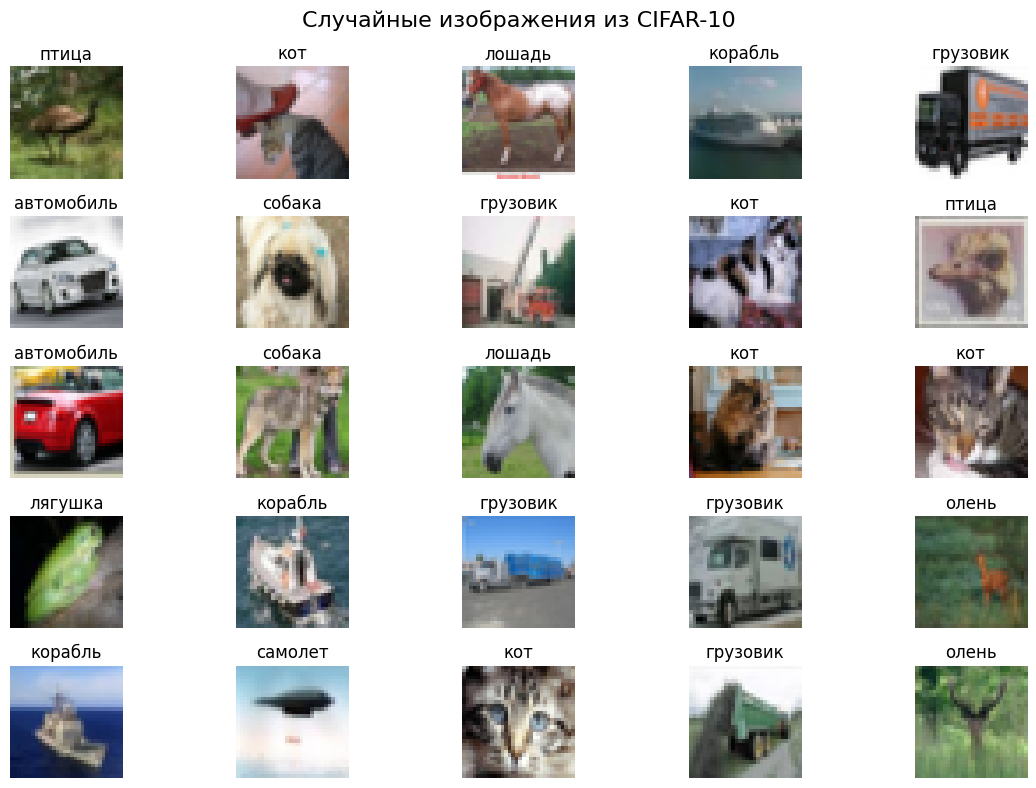

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(25):
    index = np.random.randint(0, len(X_train))
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[index])
    plt.title(classes[y_train[index][0]])
    plt.axis("off")

plt.suptitle("Случайные изображения из CIFAR-10", fontsize=16)
plt.tight_layout()
plt.show()

## Шаг 4. Визуализация изображений по классам

Отобразите по одному примеру для каждого класса.

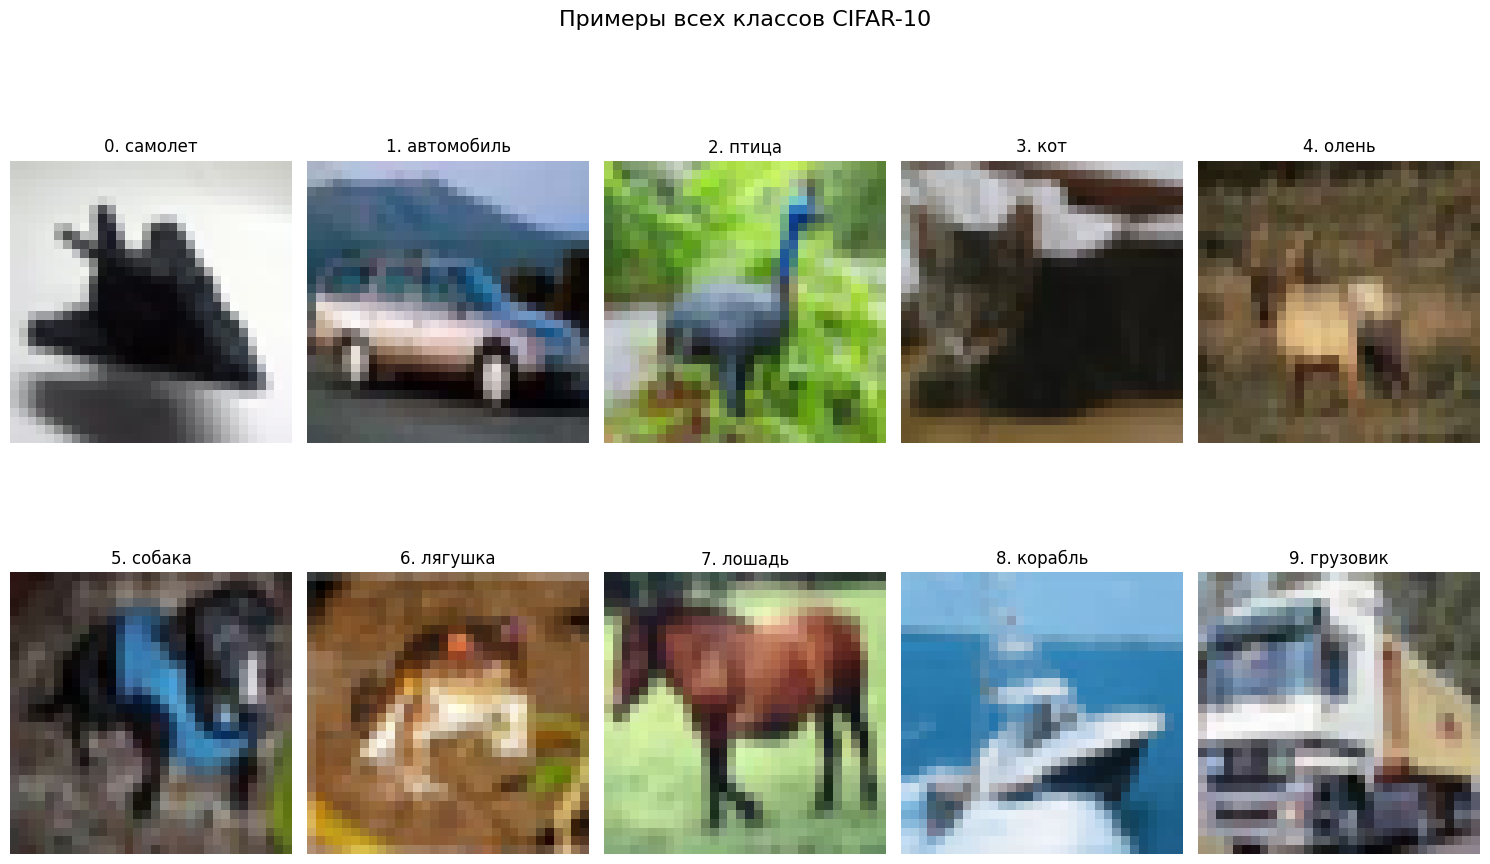

In [ ]:
plt.figure(figsize=(15, 10))

for class_id in range(10):
    indices = np.where(y_train == class_id)[0]
    first_index = indices[0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train[first_index])
    plt.title(f"{class_id}. {classes[class_id]}")
    plt.axis("off")

plt.suptitle("Примеры всех классов CIFAR-10", fontsize=16)
plt.tight_layout()
plt.show()

## Шаг 5. Подготовка данных

Перед обучением модели нужно:

1. нормализовать изображения;
2. преобразовать метки классов в one-hot encoding;
3. разделить обучающую выборку на обучающую и валидационную части.

### Нормализация

Изначально значения пикселей находятся в диапазоне от 0 до 255.  
Мы приведём их к диапазону от 0 до 1.

### One-hot encoding

Метка класса превращается в вектор длины 10.

Например, класс `3` превращается в:

```python
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
```

Данные успешно перезагружены и нормализованы
Min: 0.0, Max: 1.0


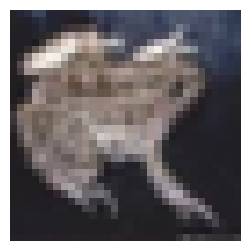

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Данные успешно перезагружены и нормализованы")
print(f"Min: {X_train.min()}, Max: {X_train.max()}")

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train, y_train_cat, test_size=0.2, random_state=42
)

plt.figure(figsize=(3, 3))
plt.imshow(X_train_new[0])
plt.axis("off")
plt.show()

## Шаг 6. Создание слоя аугментации

Создайте последовательность случайных преобразований.

Используются:

- `RandomFlip`;
- `RandomRotation`;
- `RandomZoom`;
- `RandomTranslation`;
- `RandomContrast`.

Эти слои будут изменять изображения только во время обучения модели.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1)
])


## Шаг 7. Визуализация аугментации одного изображения

Посмотрите, как одно изображение меняется после применения случайных преобразований.

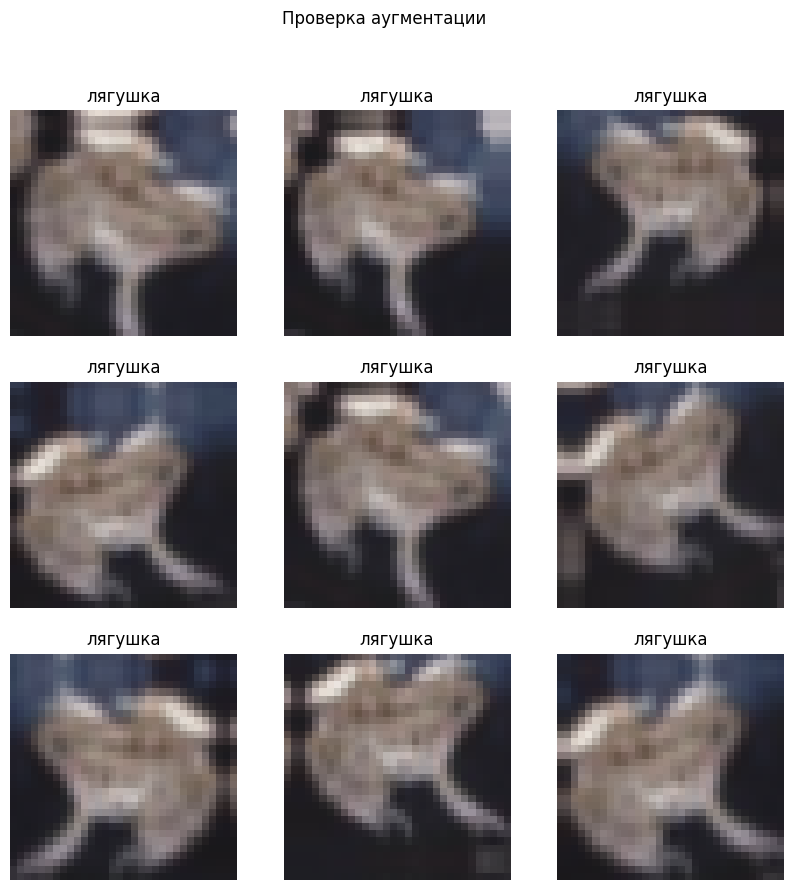

In [ ]:
image = X_train_new[0]
label = np.argmax(y_train_new[0])

plt.figure(figsize=(10, 10))
for i in range(9):

    augmented_image = data_augmentation(tf.expand_dims(image, 0), training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy())
    plt.title(classes[label])
    plt.axis("off")
plt.suptitle("Проверка аугментации")
plt.show()

## Шаг 8. Визуализация аугментации нескольких изображений

Посмотрите, как аугментация выглядит для разных классов.

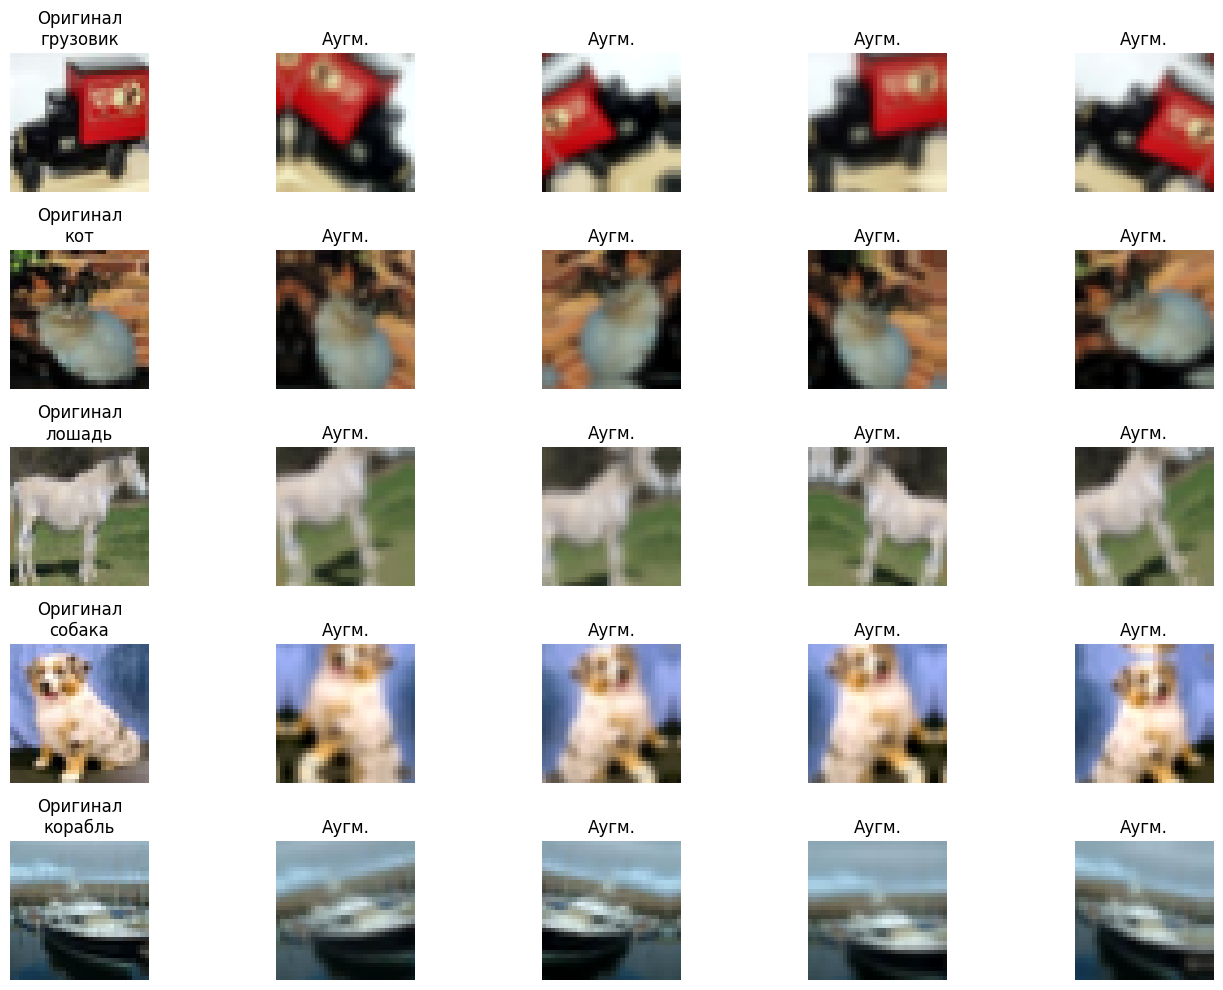

In [ ]:
plt.figure(figsize=(14, 10))
for row in range(5):
    idx = np.random.randint(0, len(X_train_new))
    img = X_train_new[idx]
    lbl = np.argmax(y_train_new[idx])

    plt.subplot(5, 5, row * 5 + 1)
    plt.imshow(img)
    plt.title(f"Оригинал\n{classes[lbl]}")
    plt.axis("off")

    for col in range(1, 5):
        aug = data_augmentation(tf.expand_dims(img, 0), training=True)
        plt.subplot(5, 5, row * 5 + col + 1)
        plt.imshow(aug[0].numpy())
        plt.title("Аугм.")
        plt.axis("off")

plt.tight_layout()
plt.show()

## Шаг 9. Создание модели CNN с аугментацией



*слой аугментации будет находиться в начале модели.



In [ ]:
from tensorflow.keras import layers, models

def create_cnn_model_with_augmentation():
    model = models.Sequential([

        data_augmentation,

        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ])

    return model

model_with_aug = create_cnn_model_with_augmentation()
model_with_aug.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (1, 32, 32, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (1, 16, 16, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (1, 16, 16, 128)       │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (1, 8, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (1, 8, 8, 512)         │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (1, 4, 4, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (1, 8192)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1, 256)               │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (1, 10)                │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,728,202 (10.41 MB)

 Trainable params: 2,728,202 (10.41 MB)

 Non-trainable params: 0 (0.00 B)

## Шаг 10. Компиляция модели



In [ ]:
model_with_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## Шаг 11. Обучение модели

Смените среду выполнения на GPU и обучите модель на 15-30 эпохах.

In [ ]:
history_with_aug = model_with_aug.fit(
    X_train_new, y_train_new,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    verbose=1
)



Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3523 - loss: 1.7682 - val_accuracy: 0.4754 - val_loss: 1.4479
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4689 - loss: 1.4679 - val_accuracy: 0.5740 - val_loss: 1.1773
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5186 - loss: 1.3394 - val_accuracy: 0.5749 - val_loss: 1.1958
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5586 - loss: 1.2450 - val_accuracy: 0.6351 - val_loss: 1.0308
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5849 - loss: 1.1754 - val_accuracy: 0.6483 - val_loss: 0.9993
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5979 - loss: 1.1345 - val_accuracy: 0.6609 - val_loss: 0.9669
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6184 - loss: 1.0829 - val_accuracy: 0.6406 - val_loss: 1.0970
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6288 - loss: 1.0553 - val_ac

## Шаг 12. Графики обучения

Постройте графики:

- точности на обучающей и валидационной выборках;
- функции потерь на обучающей и валидационной выборках.

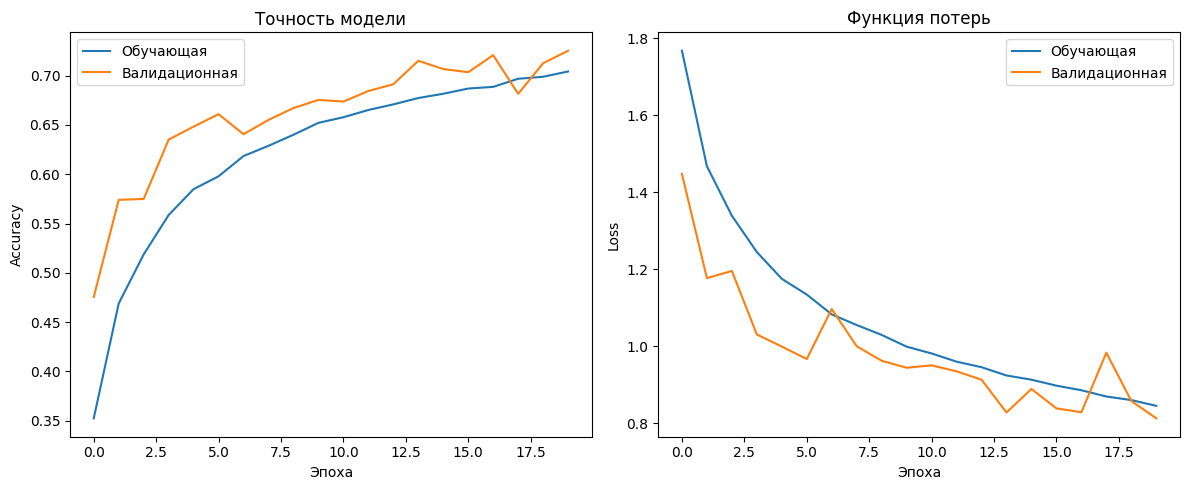

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_with_aug.history['accuracy'], label='Обучающая')
plt.plot(history_with_aug.history['val_accuracy'], label='Валидационная')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_with_aug.history['loss'], label='Обучающая')
plt.plot(history_with_aug.history['val_loss'], label='Валидационная')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Шаг 13. Оценка модели на тестовой выборке

Проверьте, как модель работает на новых данных.

In [ ]:
test_loss, test_acc = model_with_aug.evaluate(X_test, y_test_cat, verbose=0)

print(f"Тестовая точность: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Тестовый loss: {test_loss:.4f}")

Тестовая точность: 0.7207 (72.07%)
Тестовый loss: 0.8178


## Шаг 14. Предсказания модели

Посмотрите, как модель классифицирует отдельные изображения из тестовой выборки.

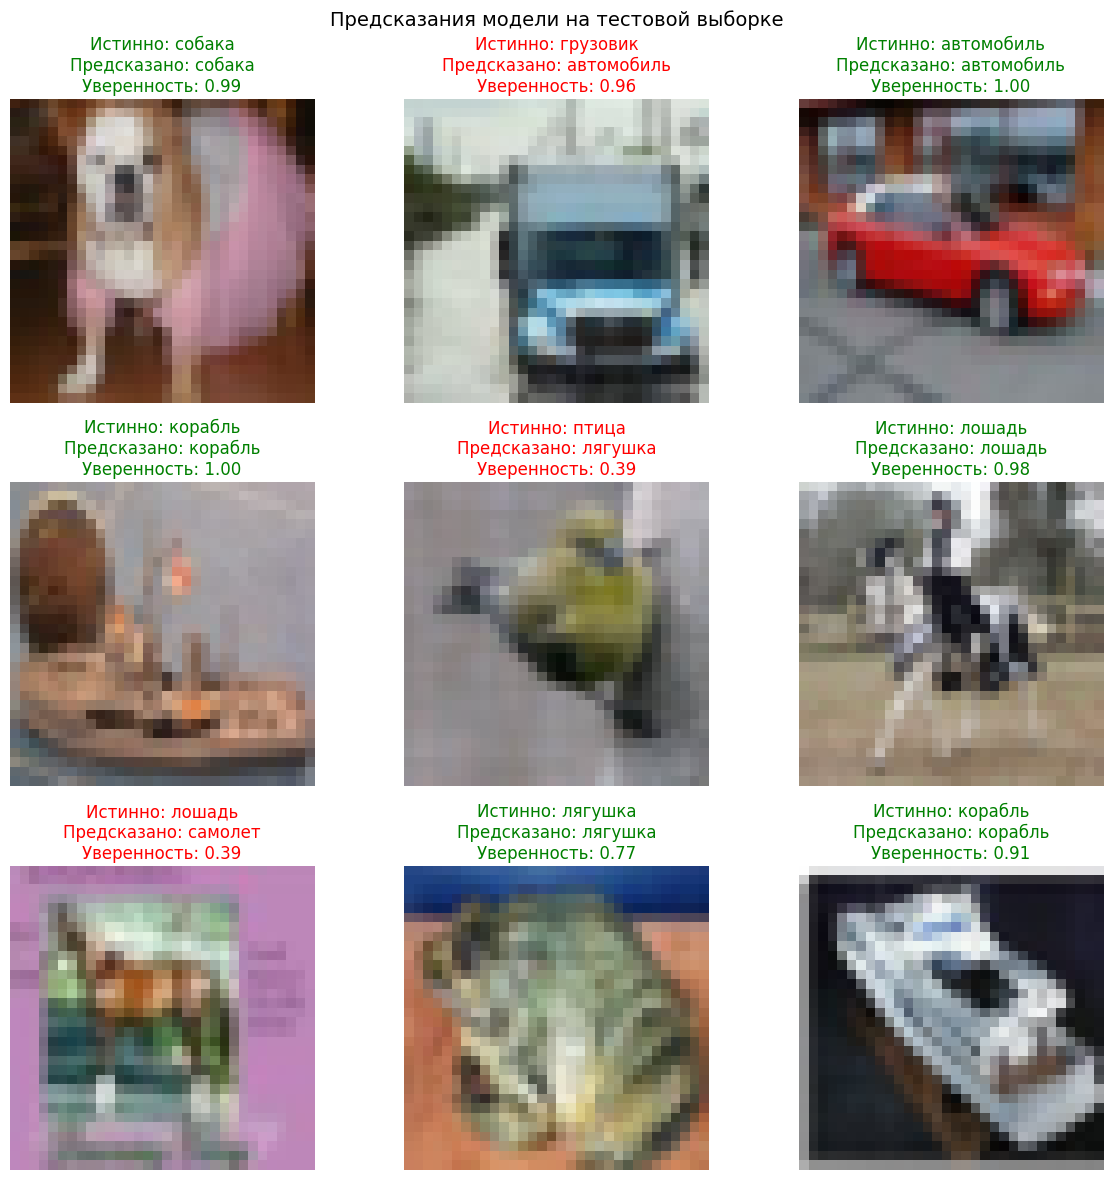

In [ ]:
indices = np.random.choice(len(X_test), 9, replace=False)

plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices):
    image = X_test[idx]
    true_label = np.argmax(y_test_cat[idx])

    prediction = model_with_aug.predict(tf.expand_dims(image, 0), verbose=0)
    pred_label = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    if pred_label == true_label:
        color = 'green'
    else:
        color = 'red'
    plt.title(f"Истинно: {classes[true_label]}\nПредсказано: {classes[pred_label]}\nУверенность: {confidence:.2f}", color=color)
    plt.axis("off")

plt.suptitle("Предсказания модели на тестовой выборке", fontsize=14)
plt.tight_layout()
plt.show()

## Шаг 15. Оцените, насколько ваша модель уверена в предсказании класса




Средняя уверенность модели: 0.7520
Медианная уверенность: 0.8220
Минимальная уверенность: 0.1427
Максимальная уверенность: 1.0000


<Figure size 1200x400 with 0 Axes>

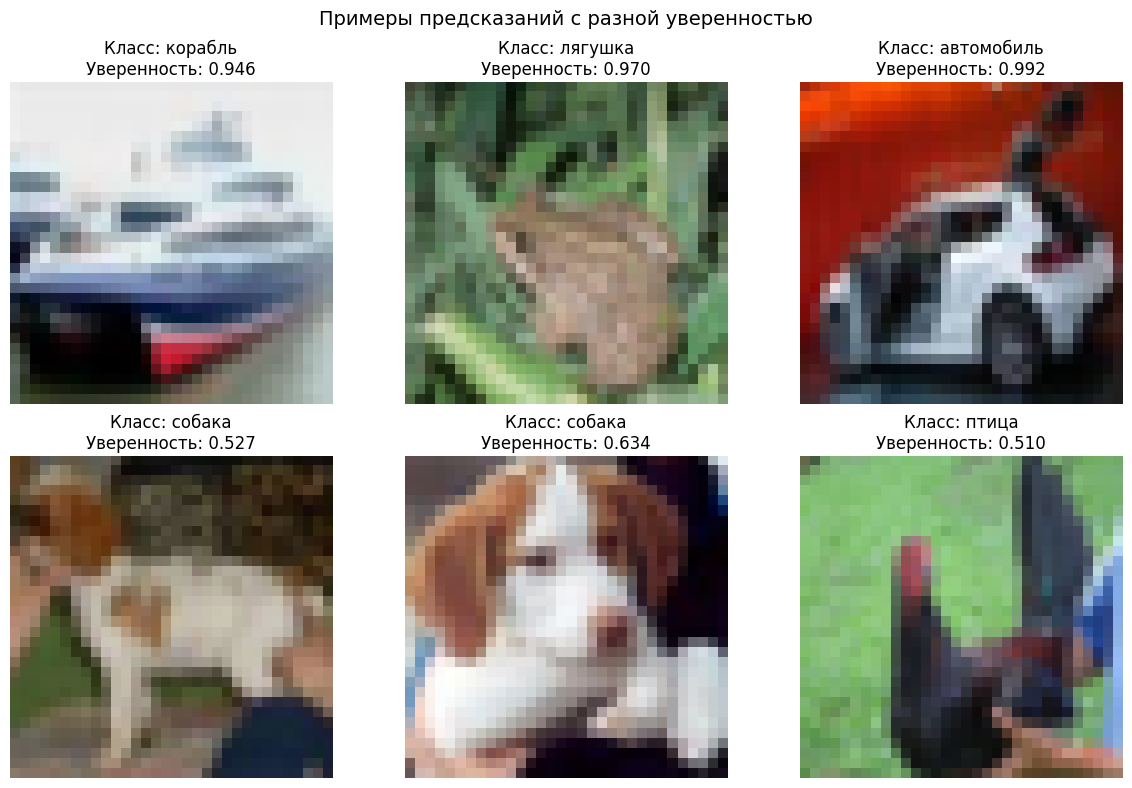

In [ ]:
predictions = model_with_aug.predict(X_test, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test_cat, axis=1)
confidences = np.max(predictions, axis=1)

print(f"\nСредняя уверенность модели: {np.mean(confidences):.4f}")
print(f"Медианная уверенность: {np.median(confidences):.4f}")
print(f"Минимальная уверенность: {np.min(confidences):.4f}")
print(f"Максимальная уверенность: {np.max(confidences):.4f}")

plt.figure(figsize=(12, 4))

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Примеры предсказаний с разной уверенностью', fontsize=14)

high_conf_idx = np.where(confidences > 0.9)[0][:3]
mid_conf_idx = np.where((confidences >= 0.5) & (confidences <= 0.7))[0][:3]

for i, idx in enumerate(high_conf_idx):
    axes[0, i].imshow(X_test[idx])
    axes[0, i].set_title(f"Класс: {classes[true_classes[idx]]}\nУверенность: {confidences[idx]:.3f}")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Высокая уверенность", fontsize=10)

for i, idx in enumerate(mid_conf_idx):
    axes[1, i].imshow(X_test[idx])
    axes[1, i].set_title(f"Класс: {classes[true_classes[idx]]}\nУверенность: {confidences[idx]:.3f}")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_ylabel("Средняя уверенность", fontsize=10)

plt.tight_layout()
plt.show()

## Шаг 18. Матрица ошибок

Постройте матрицу ошибок, чтобы посмотреть, какие классы модель чаще всего путает между собой.

<Figure size 1200x1000 with 0 Axes>

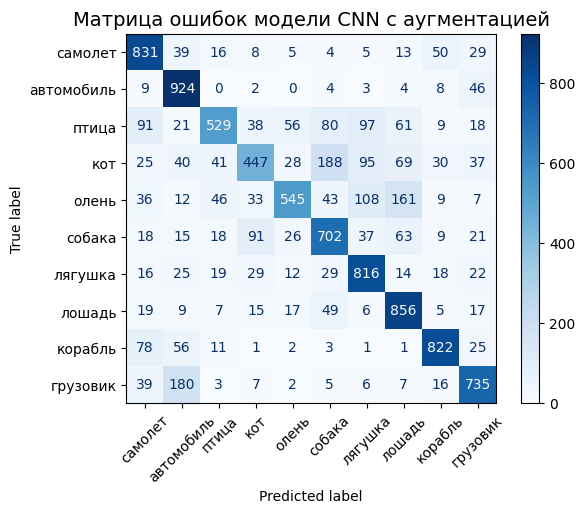


Точность по каждому классу:
   самолет     : 0.8310 (831/1000)
   автомобиль  : 0.9240 (924/1000)
   птица       : 0.5290 (529/1000)
   кот         : 0.4470 (447/1000)
   олень       : 0.5450 (545/1000)
   собака      : 0.7020 (702/1000)
   лягушка     : 0.8160 (816/1000)
   лошадь      : 0.8560 (856/1000)
   корабль     : 0.8220 (822/1000)
   грузовик    : 0.7350 (735/1000)


<Figure size 1200x1000 with 0 Axes>

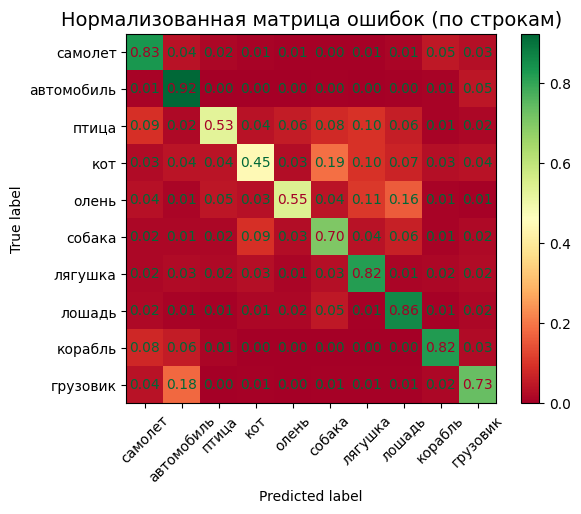

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = model_with_aug.predict(X_test, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Матрица ошибок модели CNN с аугментацией', fontsize=14)
plt.show()

errors = []
for i in range(len(true_classes)):
    if true_classes[i] != predicted_classes[i]:
        errors.append((true_classes[i], predicted_classes[i]))

from collections import Counter
error_counts = Counter(errors)
most_common_errors = error_counts.most_common(5)

print("\nТочность по каждому классу:")
for i in range(10):
    correct = np.sum((true_classes == i) & (predicted_classes == i))
    total = np.sum(true_classes == i)
    acc = correct / total if total > 0 else 0
    print(f"   {classes[i]:12}: {acc:.4f} ({correct}/{total})")

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=classes)
disp_norm.plot(cmap='RdYlGn', xticks_rotation=45, values_format='.2f')
plt.title('Нормализованная матрица ошибок (по строкам)', fontsize=14)
plt.show()

# Контрольные вопросы

1. Что такое аугментация данных? Исскустввенное увеличение обучющ выборки. добавл иск данных
2. Почему аугментация может уменьшать переобучение? выделяет общие признаки объекта
3. Какие виды аугментации использовались в этой работе?
4. Почему слишком сильная аугментация может ухудшить качество модели?
5. Почему на CIFAR-10 нужно аккуратно выбирать силу поворота и сдвига?
6. Что делает `RandomFlip("horizontal")`?
7. Что делает `RandomRotation`?
8. Что делает `RandomZoom`?
9. Почему модель с аугментацией может обучаться медленнее?
10. Как по графикам `accuracy` и `val_accuracy` определить переобучение?
11. Что показывает матрица ошибок?
12. Улучшилась ли модель после выбранной вами аугментации?